In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import pickle
import warnings
warnings.filterwarnings("ignore")

c:\Users\keert\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\keert\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("Shape:", df.shape)

df.info()

Shape: (1025, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


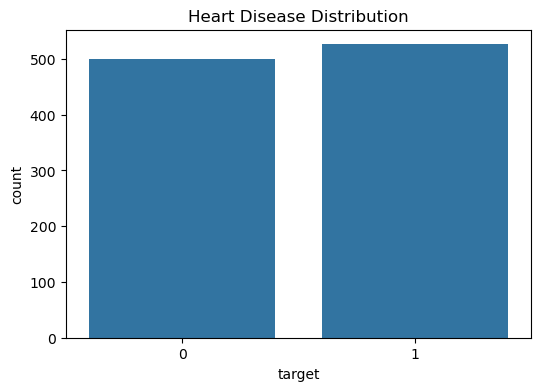

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df
)

plt.title("Heart Disease Distribution")

plt.show()

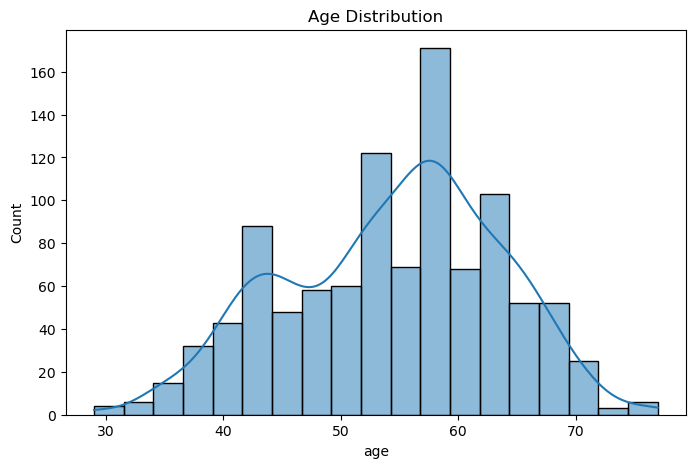

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    kde=True
)

plt.title("Age Distribution")

plt.show()

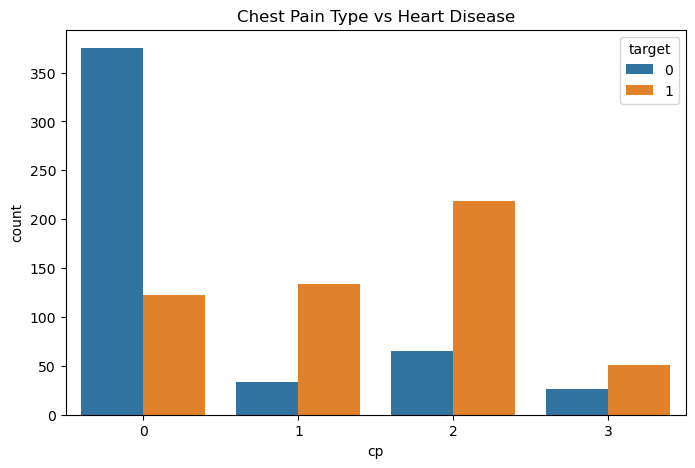

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="cp",
    hue="target",
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")

plt.show()

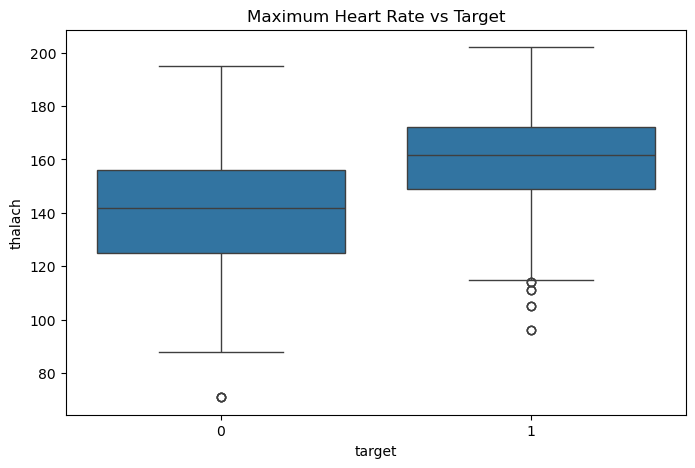

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="thalach",
    data=df
)

plt.title("Maximum Heart Rate vs Target")

plt.show()

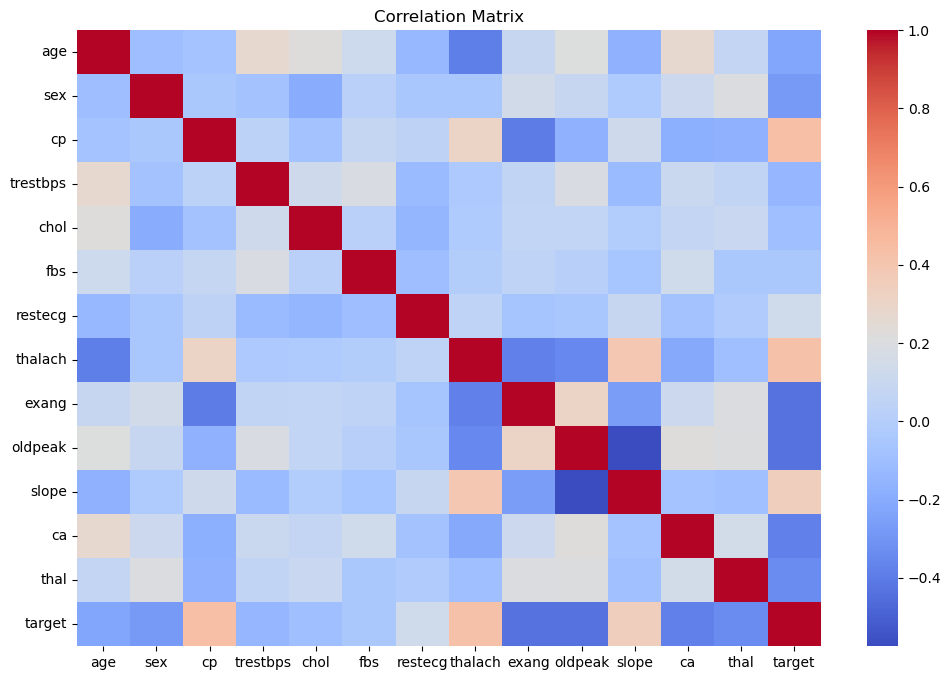

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [11]:
X = df.drop("target", axis=1)

y = df["target"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.8439024390243902


In [16]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.74      0.82       102
           1       0.78      0.95      0.86       103

    accuracy                           0.84       205
   macro avg       0.86      0.84      0.84       205
weighted avg       0.86      0.84      0.84       205



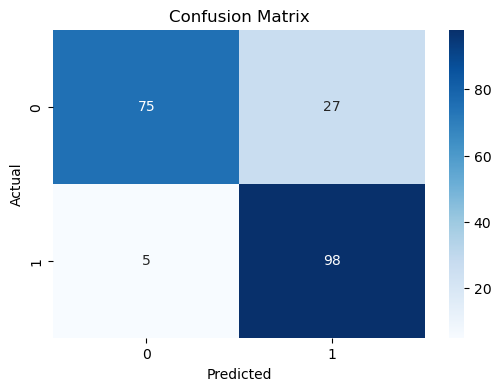

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,cp,0.350744
12,thal,0.187994
11,ca,0.136762
9,oldpeak,0.097650
7,thalach,0.064702
4,chol,0.057535
0,age,0.027860
10,slope,0.027385
3,trestbps,0.025265
8,exang,0.024104


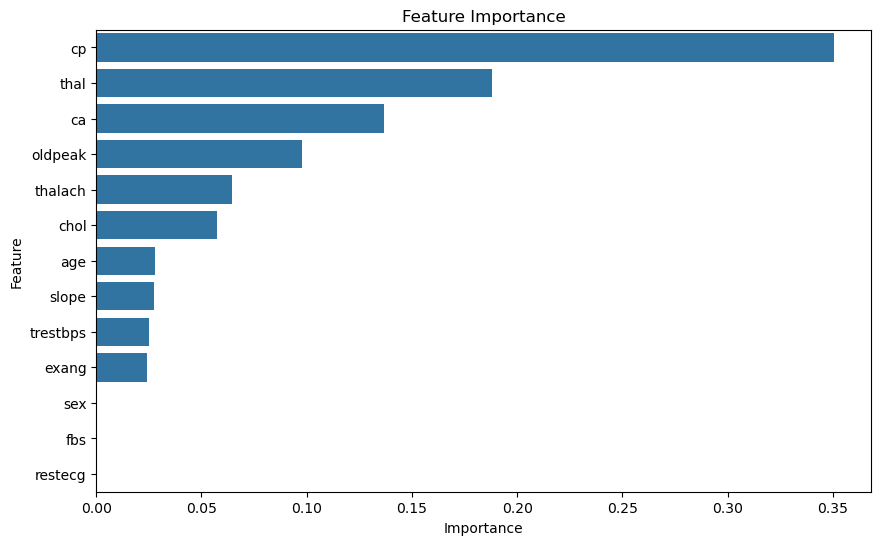

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.show()

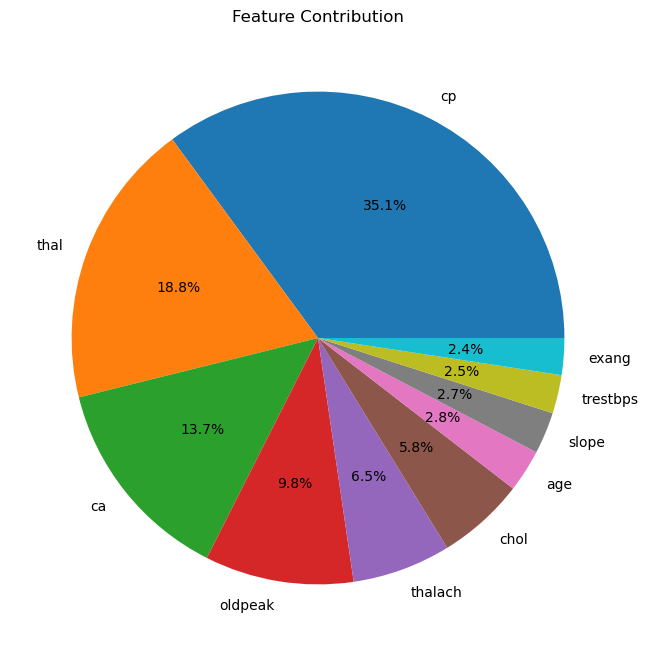

In [20]:
top = importance.head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top["Importance"],
    labels=top["Feature"],
    autopct="%1.1f%%"
)

plt.title(
    "Feature Contribution"
)

plt.show()

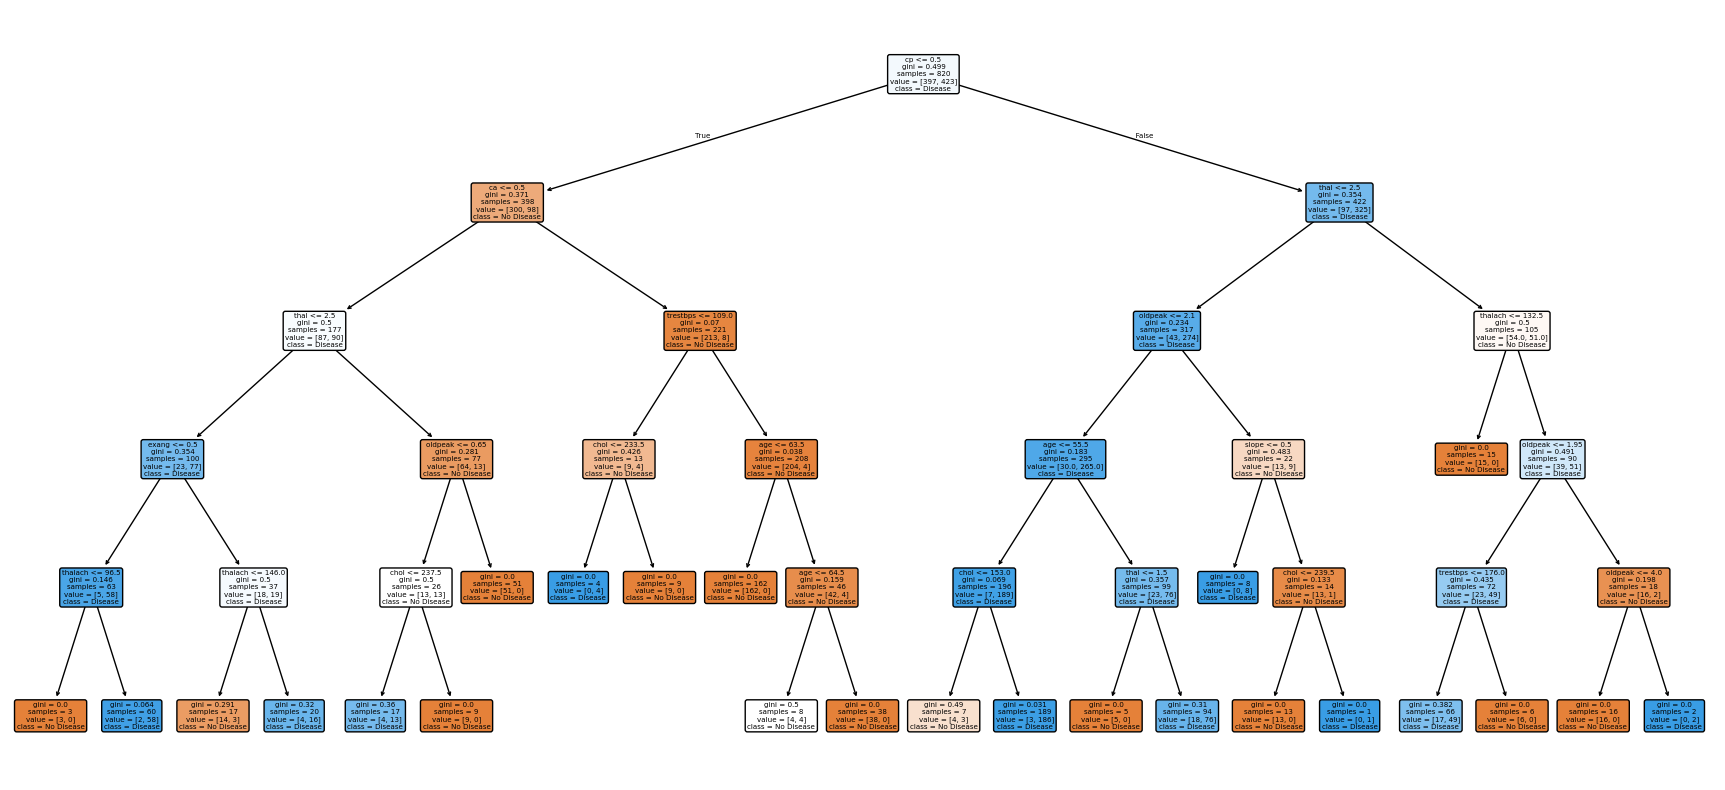

In [21]:
plt.figure(figsize=(22,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[
        "No Disease",
        "Disease"
    ],
    filled=True,
    rounded=True
)

plt.show()

In [ ]:
plt.figure(figsize=(22,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[
        "No Disease",
        "Disease"
    ],
    filled=True,
    rounded=True
)

plt.savefig(
    "heart_tree.png",
    bbox_inches="tight"
)

plt.close()

In [22]:
pickle.dump(
    model,
    open(
        "heart_disease_model.pkl",
        "wb"
    )
)

print("Model Saved")

Model Saved


In [23]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

No Heart Disease


In [24]:
import pickle
import numpy as np

model = pickle.load(open("heart_disease_model.pkl", "rb"))

sample = np.array([[
    63, 1, 3, 145, 233,
    1, 0, 150, 0,
    2.3, 0, 0, 1
]])

prediction = model.predict(sample)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Prediction: [1]
Heart Disease Detected


In [25]:
sample = np.array([[
    20,0,0,80,100,
    0,0,100,0,
    1,0,0,0
]])

print("Prediction:", model.predict(sample))
print("Probability:", model.predict_proba(sample))

Prediction: [1]
Probability: [[0.03333333 0.96666667]]


In [26]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8439024390243902


In [27]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [30]:
import pickle

pickle.dump(
    model,
    open("heart_disease_model.pkl", "wb")
)

print("New model saved successfully!")

New model saved successfully!


In [31]:
import pickle

loaded_model = pickle.load(
    open("heart_disease_model.pkl", "rb")
)

print(loaded_model)

DecisionTreeClassifier(max_depth=10, random_state=42)


In [32]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print(
    "Accuracy:",
    round(
        accuracy_score(y_test, y_pred)*100,
        2
    ),
    "%"
)

Accuracy: 98.54 %
